Using ROOT: D:\customer-support-auto-triage
{'accuracy': 1.0, 'precision_macro': np.float64(1.0), 'recall_macro': np.float64(1.0), 'f1_macro': np.float64(1.0)}

                     precision    recall  f1-score   support

Account Management       1.00      1.00      1.00         6
   Billing Inquiry       1.00      1.00      1.00         8
        Bug Report       1.00      1.00      1.00         8
   Feature Request       1.00      1.00      1.00         8
   Technical Issue       1.00      1.00      1.00        10

          accuracy                           1.00        40
         macro avg       1.00      1.00      1.00        40
      weighted avg       1.00      1.00      1.00        40

Avg latency (ms/ticket): 0.1049
Artifacts saved:
 - D:\customer-support-auto-triage\models\ticket_model.joblib 
 - D:\customer-support-auto-triage\reports\test_predictions.csv 
 - D:\customer-support-auto-triage\reports\report.json 
 - D:\customer-support-auto-triage\reports\confusion_matrix.pn

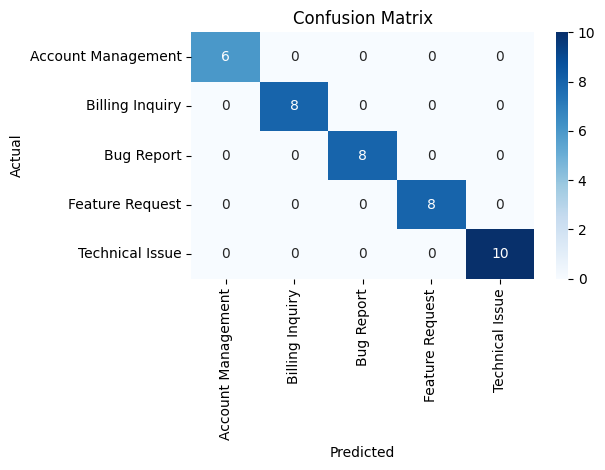

In [ ]:
# -----------------------------
# Customer Support Ticket Classification
# -----------------------------

import os, time, json
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
import seaborn as sns, matplotlib.pyplot as plt
import joblib

# 0) Resolve project root (works from notebooks/ or repo root)
ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = Path(r"D:\customer-support-auto-triage").resolve()

print("Using ROOT:", ROOT)

# 1) Paths and folders
DATA_PATH = ROOT / "data" / "customer_support_tickets.csv"
MODELS_DIR, REPORTS_DIR = ROOT / "models", ROOT / "reports"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# 2) Load data and build text
df = pd.read_csv(DATA_PATH)
df["text"] = (
    df["Subject"].fillna("").astype(str) + " " +
    df["Description"].fillna("").astype(str)
).str.lower().str.replace(r"\s+", " ", regex=True)
X, y = df["text"], df["Category"].astype(str)

# 3) Stratified split
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Pipeline: TF‑IDF + Logistic Regression
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
])

# 5) Train
t0 = time.perf_counter()
pipe.fit(Xtr, ytr)
train_time = time.perf_counter() - t0

# 6) Evaluate
yp = pipe.predict(Xte)
acc = accuracy_score(yte, yp)
p, r, f1, _ = precision_recall_fscore_support(yte, yp, average="macro")

print({"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1})
print("\n", classification_report(yte, yp))

# 7) Confusion matrix plot + save
labels = sorted(yte.unique().tolist())
cm = confusion_matrix(yte, yp, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.title("Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight")

# 8) Latency (avg ms per ticket on this machine)
t0 = time.perf_counter()
_ = pipe.predict(Xte)
avg_ms = (time.perf_counter() - t0) * 1000 / max(len(Xte), 1)
print(f"Avg latency (ms/ticket): {avg_ms:.4f}")

# 9) Save artifacts and report
model_path  = MODELS_DIR / "ticket_model.joblib"
preds_path  = REPORTS_DIR / "test_predictions.csv"
report_path = REPORTS_DIR / "report.json"

joblib.dump(pipe, model_path)
pd.DataFrame({
    "Ticket_ID": df.loc[Xte.index, "Ticket_ID"],
    "true": yte, "pred": yp
}).to_csv(preds_path, index=False)

with open(report_path, "w", encoding="utf-8") as f:
    json.dump({
        "training_time_s": round(train_time, 3),
        "accuracy": round(acc, 4),
        "precision_macro": round(p, 4),
        "recall_macro": round(r, 4),
        "f1_macro": round(f1, 4),
        "avg_latency_ms_per_ticket": round(avg_ms, 4),
        "labels": labels
    }, f, indent=2)

print("Artifacts saved:\n -", model_path, "\n -", preds_path, "\n -", report_path, "\n -", REPORTS_DIR / "confusion_matrix.png")